In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from clean_and_combine import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/Probe_noise/')

%load_ext autoreload
%autoreload 2

# Post processing of wave tank experiment data and instrument noise
### Master thesis of Kjersti Stangeland, University of Oslo
*2025/2026 kjesta@uio.no*

## Noise measurement

Water level measurements from the Hydrodynamics laboratory at University of Oslo, contributing to my thesis, where done with four acoustic probes of the type *USS02/HFP* from *General Acoustics*.
The probe settings used were:
* Sample rate of 250 Hz (high)
* Resolution: 0.18 mm

The signals recorded by the probes were processed by a software named *UltraLab Advanced Controller*, which converts the acoustic signal to distance in meters. Further, the processed data is sent to *UltraLab: Ultralab Monitoring Software* which displays the data and allows for saving the experiment runs. The 27th of November 2025, I conducted a probe noise measurement. For 120 seconds, the four probes recorded the water level of stil water at 20 cm depth. Here are the results.

In [2]:
path = '/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/Probe_noise/probe_noise_271125.csv'
df = pd.read_csv(path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']
df.columns = headers

df.head()

,time,P_0,P_1,P_2,P_3,sound_speed
0,11/27/2025 16:03:49.492,0.27363,0.27286,0.27372,0.27329,343.12
1,11/27/2025 16:03:49.496,0.27363,0.27278,0.27372,0.27329,343.12
2,11/27/2025 16:03:49.500,0.27363,0.27286,0.27372,0.27329,343.12
3,11/27/2025 16:03:49.504,0.27372,0.27286,0.27372,0.27329,343.12
4,11/27/2025 16:03:49.508,0.27372,0.27286,0.27372,0.27329,343.12


In [4]:
# Mean of each probe, raw data
mean_P0_raw = np.mean(df['P_0'])
mean_P1_raw = np.mean(df['P_1'])
mean_P2_raw = np.mean(df['P_2'])
mean_P3_raw = np.mean(df['P_3'])

Text(0.5, 0.98, 'Probe Noise Signals (No Wave Generation)')

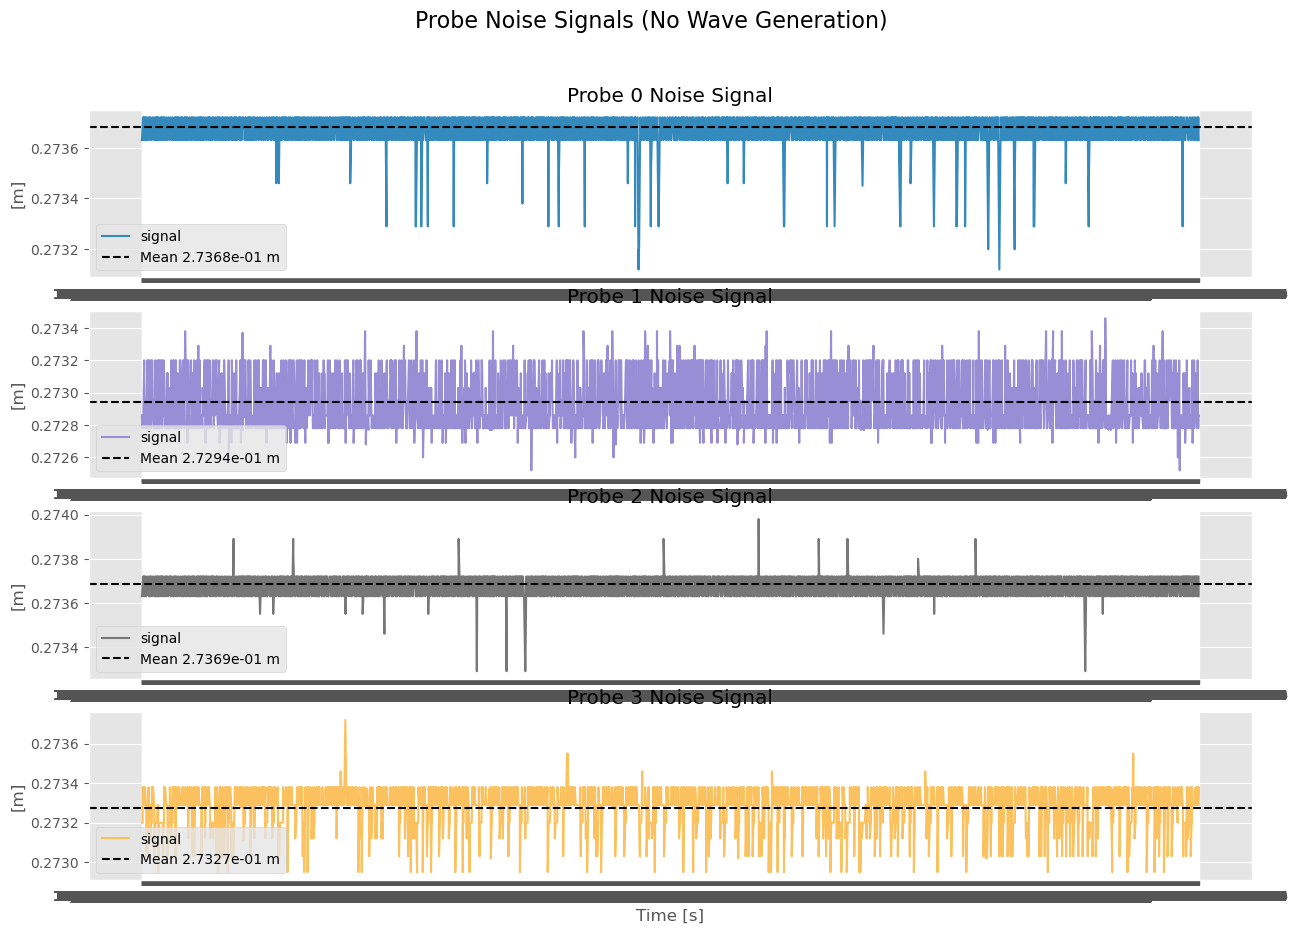

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10))

ax[0].plot(df['time'][10000:], df['P_0'][10000:], label='signal', color='C1')
ax[0].axhline(mean_P0_raw, color='k', linestyle='--', label=f'Mean {mean_P0_raw:.4e} m')
ax[0].legend(loc='lower left')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')

ax[1].plot(df['time'][10000:], df['P_1'][10000:], label='signal', color='C2')
ax[1].axhline(mean_P1_raw, color='k', linestyle='--', label=f'Mean {mean_P1_raw:.4e} m')
ax[1].legend(loc='lower left')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')

ax[2].plot(df['time'][10000:], df['P_2'][10000:], label='signal', color='C3')
ax[2].axhline(mean_P2_raw, color='k', linestyle='--', label=f'Mean {mean_P2_raw:.4e} m')
ax[2].legend(loc='lower left')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')

ax[3].plot(df['time'][10000:], df['P_3'][10000:], label='signal', color='C4')
ax[3].axhline(mean_P3_raw, color='k', linestyle='--', label=f'Mean {mean_P3_raw:.4e} m')
ax[3].legend(loc='lower left')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')

fig.suptitle('Probe Noise Signals (No Wave Generation)', fontsize=16)

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(df['time'][0:250], df['P_0'][0:250], label='signal', color='C1')
ax[0].axhline(mean_P0_raw, color='k', linestyle='--', label=f'Mean {mean_P0_raw:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(df['time'][0:250], df['P_1'][0:250], label='signal', color='C2')
ax[1].axhline(mean_P1_raw, color='k', linestyle='--', label=f'Mean {mean_P1_raw:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(df['time'][0:250], df['P_2'][0:250], label='signal', color='C3')
ax[2].axhline(mean_P2_raw, color='k', linestyle='--', label=f'Mean {mean_P2_raw:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(df['time'][0:250], df['P_3'][0:250], label='signal', color='C4')
ax[3].axhline(mean_P3_raw, color='k', linestyle='--', label=f'Mean {mean_P3_raw:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

### Magnitude of noise per probe

In [ ]:
std_P0 = np.std(df['P_0'])
std_P1 = np.std(df['P_1'])
std_P2 = np.std(df['P_2'])
std_P3 = np.std(df['P_3'])

In [ ]:
print(f'Standard Deviation Probe 0: {std_P0:.6f} m = {std_P0*1000:.2f} mm')
print(f'Standard Deviation Probe 1: {std_P1:.6f} m = {std_P1*1000:.2f} mm')
print(f'Standard Deviation Probe 2: {std_P2:.6f} m = {std_P2*1000:.2f} mm')
print(f'Standard Deviation Probe 3: {std_P3:.6f} m = {std_P3*1000:.2f} mm')

Signals larger than the standard deviation of the probe can be trusted as a true signal, and not a probe artefact.

# Post processing
I have a few methods for processing the raw data. 
1) Cleaning - taking the mean of the first 250 datapoints (1 second of measurement) per probe, and subtracting it from the entire column of data. This should remove the mean noise.
2) Filtering - correct for large outliers with a window checking to see if a value deviates from its neighbours above a set tolerance. Then, applies a weighted average for 2 passes, smoothing the data.
3) Detrending - taking the mean of each probe column and subtracting it from the column. This ensures that the wave signal is centered around z=0 (still water level).

I will show how the post processing affects both the noise measurement and an example on how it affects wave measurements.

In [ ]:
# Example experiment with waves
base_path = '/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/20cm/f11/a03'

r1_path = os.path.join(base_path, 'f11a03h02r1.csv')
r2_path = os.path.join(base_path, 'f11a03h02r2.csv')
r3_path = os.path.join(base_path, 'f11a03h02r3.csv')

r1_raw = pd.read_csv(r1_path)
r2_raw = pd.read_csv(r2_path)
r3_raw = pd.read_csv(r3_path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_raw.columns = headers
r2_raw.columns = headers
r3_raw.columns = headers

# 1) Cleaning - Remove noise (probe artefacts) and convert time to seconds
r1_clean = clean(r1_raw)
r2_clean = clean(r2_raw)
r3_clean = clean(r3_raw)

# 2) Filtering - Apply low pass filter
r1_filtered = low_pass(r1_clean)
r2_filtered = low_pass(r2_clean)
r3_filtered = low_pass(r3_clean)

# 3) Detrend data
# The probes are not perfectly leveled above the water surface, causing a slight linear trend in the data.
# To remove this, we detrend the data by subtracting the mean from each column.
r1_detrended = detrend(r1_filtered)
r2_detrended = detrend(r2_filtered)
r3_detrended = detrend(r3_filtered)

# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    print(np.mean(r1_detrended[col]), np.mean(r2_detrended[col]), np.mean(r3_detrended[col]))

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(14, 12), sharex='col')

ax[0, 0].plot(r1_raw['time'], r1_raw['P_0'], label='Raw P0', color='C0')
ax[1, 0].plot(r1_clean['time'], r1_clean['P_0'], label='Cleaned P0', color='C1')
ax[2, 0].plot(r1_filtered['time'], r1_filtered['P_0'], label='Filtered P0', color='C2')
ax[3, 0].plot(r1_detrended['time'], r1_detrended['P_0'], label='Detrended P0', color='C3')

ax[0, 0].set_title('Raw')
ax[1, 0].set_title('Cleaned')
ax[2, 0].set_title('Cleaned + Filtered')
ax[3, 0].set_title('Cleaned + Filtered + Detrended')

ax[0, 1].plot(r1_raw['time'], r1_raw['P_0'], label='Raw (repeat)', color='C0', alpha=0.6)
ax[1, 1].plot(r1_clean['time'], np.abs(r1_clean['P_0'] - r1_raw['P_0']), label='abs(Clean - Raw)', color='C1')
ax[2, 1].plot(r1_filtered['time'], np.abs(r1_filtered['P_0'] - r1_clean['P_0']), label='abs(Filtered - Clean)', color='C2')
ax[3, 1].plot(r1_detrended['time'], np.abs(r1_detrended['P_0'] - r1_filtered['P_0']), label='abs(Detrended - Filtered)', color='C3')

ax[0, 1].set_title('Raw (for reference)')
ax[1, 1].set_title('Effect of Cleaning')
ax[2, 1].set_title('Effect of Filtering')
ax[3, 1].set_title('Effect of Detrending')

for row in range(4):
    for col in range(2):
        ax[row, col].legend(loc='upper right', fontsize='small')

fig.suptitle(f'Run 1 - Probe P_0  \n{freq} Hz, {amp} V, {depth} m', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

### How processing affects noise

In [ ]:
# 1) Cleaning of the noise run
cleaned = clean(df)

In [ ]:
# Mean of each probe after cleaning
mean_P0_clean = np.mean(cleaned['P_0'])
mean_P1_clean = np.mean(cleaned['P_1'])
mean_P2_clean = np.mean(cleaned['P_2'])
mean_P3_clean = np.mean(cleaned['P_3'])

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(clean['time'][0:250], clean['P_0'][0:250], label = 'signal', color='C1')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].axhline(mean_P0_clean, color='k', linestyle='--', label=f'Mean {mean_P0_clean:.4e} m')
ax[0].legend(loc='lower left')

ax[1].plot(clean['time'][0:250], clean['P_1'][0:250], label = 'signal', color='C2')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].axhline(mean_P1_clean, color='k', linestyle='--', label=f'Mean {mean_P1_clean:.4e} m')
ax[1].legend(loc='lower left')

ax[2].plot(clean['time'][0:250], clean['P_2'][0:250], label = 'signal', color='C3')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].axhline(mean_P2_clean, color='k', linestyle='--', label=f'Mean {mean_P2_clean:.4e} m')
ax[2].legend(loc='lower left')

ax[3].plot(clean['time'][0:250], clean['P_3'][0:250], label = 'signal', color='C4')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].axhline(mean_P3_clean, color='k', linestyle='--', label=f'Mean {mean_P3_clean:.4e} m')
ax[3].legend(loc='lower left')

fig.suptitle('Cleaned Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

In [ ]:
filtered = low_pass(clean)

In [ ]:
# Mean of each probe after cleaning and filtering
mean_P0_filtered = np.mean(filtered['P_0'])
mean_P1_filtered = np.mean(filtered['P_1'])
mean_P2_filtered = np.mean(filtered['P_2'])
mean_P3_filtered = np.mean(filtered['P_3'])

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(filtered['time'][0:250], filtered['P_0'][0:250], label='signal', color='C1')
ax[0].axhline(mean_P0_filtered, color='k', linestyle='--', label=f'Mean {mean_P0_filtered:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(filtered['time'][0:250], filtered['P_1'][0:250], label='signal', color='C2')
ax[1].axhline(mean_P1_filtered, color='k', linestyle='--', label=f'Mean {mean_P1_filtered:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(filtered['time'][0:250], filtered['P_2'][0:250], label='signal', color='C3')
ax[2].axhline(mean_P2_filtered, color='k', linestyle='--', label=f'Mean {mean_P2_filtered:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(filtered['time'][0:250], filtered['P_3'][0:250], label='signal', color='C4')
ax[3].axhline(mean_P3_filtered, color='k', linestyle='--', label=f'Mean {mean_P3_filtered:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Filtered Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

In [ ]:
detrended = detrend(filtered)

In [ ]:
# Mean of each probe after cleaning and filtering and detrending
mean_P0_detrended = np.mean(detrended['P_0'])
mean_P1_detrended = np.mean(detrended['P_1'])
mean_P2_detrended = np.mean(detrended['P_2'])
mean_P3_detrended = np.mean(detrended['P_3'])

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(detrended['time'][0:250], detrended['P_0'][0:250], label='signal', color='C1')
ax[0].axhline(mean_P0_detrended, color='k', linestyle='--', label=f'Mean {mean_P0_detrended:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(detrended['time'][0:250], detrended['P_1'][0:250], label='signal', color='C2')
ax[1].axhline(mean_P1_detrended, color='k', linestyle='--', label=f'Mean {mean_P1_detrended:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(detrended['time'][0:250], detrended['P_2'][0:250], label='signal', color='C3')
ax[2].axhline(mean_P2_detrended, color='k', linestyle='--', label=f'Mean {mean_P2_detrended:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(detrended['time'][0:250], detrended['P_3'][0:250], label='signal', color='C4')
ax[3].axhline(mean_P3_detrended, color='k', linestyle='--', label=f'Mean {mean_P3_detrended:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Detrended Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

In [ ]:
# Effect of each step visualized for Probe 0
fig, ax = plt.subplots(4, 2, figsize=(15, 10), sharex=True)
ax[0, 0].plot(df['time'], df['P_0'], label='Raw Signal', color='C1')
ax[0, 0].axhline(mean_P0_raw, color='k', linestyle='--', label=f'Mean {mean_P0_raw:.4e} m')
ax[0, 0].set_ylabel('[m]')
ax[0, 0].set_title('Raw data')
ax[0, 0].legend(loc='lower left')

ax[1, 0].plot(clean['time'], clean['P_0'], label='Cleaned Signal', color='C2')
ax[1, 0].axhline(mean_P0_clean, color='k', linestyle='--', label=f'Mean {mean_P0_clean:.4e} m')
ax[1, 0].set_ylabel('[m]')
ax[1, 0].set_title('Cleaned data')
ax[1, 0].legend(loc='lower left')  

ax[2, 0].plot(filtered['time'], filtered['P_0'], label='Filtered Signal', color='C3')
ax[2, 0].axhline(mean_P0_filtered, color='k', linestyle='--', label=f'Mean {mean_P0_filtered:.4e} m')
ax[2, 0].set_ylabel('[m]')
ax[2, 0].set_title('Cleaned and filtered data')
ax[2, 0].legend(loc='lower left')  

ax[3, 0].plot(detrended['time'], detrended['P_0'], label='Detrended Signal', color='C4')
ax[3, 0].axhline(mean_P0_detrended, color='k', linestyle='--', label=f'Mean {mean_P0_detrended:.4e} m')
ax[3, 0].set_xlabel('Time [s]')
ax[3, 0].set_ylabel('[m]') 
ax[3, 0].set_title('Cleaned, filtered and detrended data')
ax[3, 0].legend(loc='lower left')

ax[0, 1].plot(df['time'], df['P_0'], alpha = 0.7, label='Raw Signal', color='C1')
ax[0, 1].legend(loc='lower left')

ax[1, 1].plot(clean['time'], df['P_0'] - clean['P_0'], label='Raw - Clean', color='C2')
ax[1, 1].legend(loc='lower left')
ax[1,1].set_ylabel('[m]') 
ax[1,1].set_title('Difference after Cleaning') 

ax[2, 1].plot(filtered['time'], clean['P_0'] - filtered['P_0'], label='Clean - Filtered', color='C3')
ax[2, 1].legend(loc='lower left')
ax[2,1].set_ylabel('[m]') 
ax[2,1].set_title('Difference after Filtering')

ax[3, 1].plot(detrended['time'], filtered['P_0'] - detrended['P_0'], label='Filtered - Detrended', color='C4')
ax[3, 1].legend(loc='lower left')
ax[3,1].set_xlabel('Time [s]')
ax[3,1].set_ylabel('[m]') 
ax[3,1].set_title('Difference after Detrending')    

fig.suptitle('Effect of Cleaning, Filtering and Detrending on Probe 0 Noise Signal', fontsize=16)